In [ ]:
%matplotlib inline
# create source catalogs like done in pjpipe

# use with IRAFStarFinder https://photutils.readthedocs.io/en/stable/api/photutils.detection.IRAFStarFinder.html#photutils.detection.IRAFStarFinder

# this notebook is based on https://qosmicqi.github.io/XRBID/chapters/photometry.html#sec-runphots
# and https://www.astropy.org/ccd-reduction-and-photometry-guide/v/pdev/notebooks/photometry/00.00-Preface.html

import glob 

from astropy.io import fits
from astropy.wcs import WCS
from astropy.stats import SigmaClip
from astropy.stats import sigma_clipped_stats
import astropy.units as u

from photutils.background import Background2D, MedianBackground
from photutils.detection import IRAFStarFinder
from photutils.aperture import CircularAperture, CircularAnnulus
from photutils.aperture import aperture_photometry
from photutils.profiles import CurveOfGrowth

import matplotlib.pyplot as plt
import numpy as np
from stdatamodels.jwst.datamodels import ImageModel

def convert_countsum_to_abmag(aperture_sum, header):

     # aperture sum here needs to be in electrom/s

     photflam = float(header['PHOTFLAM']) * (u.erg / (u.cm**2 * u.s * u.AA))
     photplam = float(header['PHOTPLAM']) * u.AA

     abmag_zp = (- 2.5 * np.log10(photflam)) - 21.10 - (5 * np.log10(photplam)) + 18.6921

     # C = aperture summed count rate in electron/s (ap corrected to the standard 5.5'' radius)
     abmag = -2.5 * np.log10(aperture_sum) + abmag_zp

     return abmag

def convert_aperture_sum_Jy_per_sr_to_abmag(aperture_sum_jy_sr, header):
     # here aperture_sum must be in Jy/sr
     pix_area_sr = get_pixarea_in_sr(header)
     fnu_jy = np.array(aperture_sum_jy_sr) * pix_area_sr
     fnu_jy = np.where(fnu_jy > 0, fnu_jy, np.nan)
     abmag = -2.5 * np.log10(fnu_jy / 3631.0)
     return abmag

def get_photfnu(header):
     if 'PHOTFNU' in header:
          return float(header['PHOTFNU'])
     
     elif 'PHOTFLAM' in header and 'PHOTPLAM' in header:
          photflam = float(header['PHOTFLAM']) * (u.erg / (u.cm**2 * u.s * u.AA))
          photplam = float(header['PHOTPLAM']) * u.AA
          photfnu = photflam.to(u.Jy, equivalencies=u.spectral_density(photplam))

          return float(photfnu.value)
     
     else:
          raise ValueError(f"Header does not contain keyword to obtain PHOTFNU value")

def get_pixarea_in_sr(header):
     if 'PIXAR_SR' in header:
          return float(header['PIXAR_SR'])

     elif ('CDELT1' in header) and ('CDELT2' in header):
          area_deg2 = np.abs(float(header['CDELT1']) * float(header['CDELT2']))
          if np.isfinite(area_deg2) and (area_deg2 > 0):
               return float((area_deg2 * u.deg**2).to(u.sr).value)

     elif 'CD1_1' in header:
          cd = np.array([[float(header['CD1_1']), float(header['CD1_2'])],
                         [float(header['CD2_1']), float(header['CD2_2'])]])
          area_deg2 = np.abs(np.linalg.det(cd))
          return float((area_deg2 * u.deg**2).to(u.sr).value)

     else:
         raise ValueError("could not get pixel area in steradians from header/WCS")

def transform_to_Jy_sr(img, err, header):
     photfnu = get_photfnu(header)
     pix_area_sr = get_pixarea_in_sr(header)

     factor = photfnu / pix_area_sr
     img_jy_sr = img * factor
     err_jy_sr = err * factor

     return img_jy_sr, err_jy_sr, factor

def transform_jy_sr_to_abmag_arcsec2(sb_jy_sr):
     sb_jy_sr = np.array(sb_jy_sr) # imagen from transform_to_Jy_sr
     sb_jy_sr = np.where(sb_jy_sr > 0, sb_jy_sr, np.nan)
     sr_per_arcsec2 = 2.3504431e-11
     abmag_arcsec2 = -2.5 * np.log10(sb_jy_sr * sr_per_arcsec2) + 8.90
     return abmag_arcsec2     

def open_hst(gal, dir, band, get_coverage=True):
     # this is working only because I downloaded a subset of the folder in https://drive.google.com/drive/folders/1ZAWNoah7iDPEDa7PYIZP5gyGVToV0B4_
     print(f"searching in {dir}{gal}/*{band}*/*{band}*.fits")
     files = glob.glob(f"{dir}{gal}/*{band}*/*{band}*.fits")
     print(f"files found: {files}")
     for file in files:
          if 'exp' in file:
               img_file = file 
          elif 'err' in file:
               err_file = file
     print(f"img_file: {img_file}")
     print(f"err_file: {err_file}")

     with fits.open(img_file) as hdul:
          img = hdul[0].data
          header = hdul[0].header 
     with fits.open(err_file) as hdul:
          err = hdul[0].data
          err_header = hdul[0].header



     snr_map = img / err

     if get_coverage:
          coverage_mask = (~np.isfinite(img)) | (img == 0)

     return img, err, snr_map, coverage_mask, header

def subtract_bkg(img, box_size=(500,500), filter_size=(3, 3), coverage_mask = None):
     # estimate background
     # to do: need to include valid mask based on weight image or other metric
     sigma_clip = SigmaClip(sigma=3.0)

     if coverage_mask is None:
          print(f"creating coverage mask")
          coverage_mask = (~np.isfinite(img)) | (img == 0)

     bkg = Background2D(
          img,
          box_size=box_size,
          filter_size=filter_size,
          sigma_clip=sigma_clip,
          bkg_estimator=MedianBackground(),
          coverage_mask=coverage_mask,
          )

     rms_map = np.array(bkg.background_rms, dtype=float)
     valid_rms = (~coverage_mask) & np.isfinite(rms_map) & (rms_map > 0)

     #print(f"bkg array {bkg.background}")
     bkg_rms = np.nanmedian(rms_map[valid_rms]) if np.any(valid_rms) else np.nan
     bkg_mean = np.nanmean(np.asarray(bkg.background, dtype=float)[~coverage_mask])
     print(f"mean bkg {bkg_mean}")
     print(f"background rms {bkg_rms}")

     print(f"subtracting background")
     img_sub = img - bkg.background

     return img_sub, bkg_mean, bkg_rms

def run_source_finder(
     img, 
     header, 
     rms, 
     finder='iraf',
     snr_threshold=3.0,
     fwhm=2.0,
     roundlo=-0.5, 
     roundhi=0.5,
     sharplo=0.2, 
     sharphi=1.0,
     brightest=20000,
     ):
     print("running source finder")
     ths = snr_threshold * rms
     finder = IRAFStarFinder(threshold=ths,
                             fwhm=fwhm,
                             roundlo=roundlo,
                             roundhi=roundhi,
                             sharplo=sharplo,
                             sharphi=sharphi,
                             brightest=brightest,
                             )
     
     sources = finder(img)
     print(f"found {len(sources)} sources")
     print(sources.colnames)

     return sources

def get_optimal_aperture(data, sources, max_r=32, brightest=50, frac=0.95, plot=True):
     if brightest is not None:
          sources = sources[np.argsort(sources['flux'])[-brightest:]]
          print(f"using only {len(sources)} sources")

     print("doing aperture photometry")
     positions = np.transpose((sources['xcentroid'], sources['ycentroid']))
     radii = np.arange(1, max_r)

     # define in and outer annuli for local background estimation
     ann_in, ann_out = max_r + 2, max_r + 8
     ann = CircularAnnulus(positions, r_in=ann_in, r_out=ann_out)

     # get local backgrounds
     ann_phot = aperture_photometry(data, ann)
     bkg_mean = np.asarray(ann_phot["aperture_sum"]) / ann.area

     # at each radii compute photometry
     fluxes = []
     for r in radii:
          ap = CircularAperture(positions, r=r)
          phot = aperture_photometry(data, ap)

          # subtract local background
          src = np.asarray(phot["aperture_sum"]) - bkg_mean * ap.area
          fluxes.append(src)

     # normalize fluxes
     fluxes = np.asarray(fluxes).T

     norm = fluxes / fluxes[:, [-1]]
     norm[~np.isfinite(norm)] = np.nan

     # comptue median normalized flux
     median_curve = np.nanmedian(norm, axis=0)  

     idx = np.where(median_curve >= frac)[0]
     r_opt = radii[idx[0]] if len(idx) else radii[np.nanargmax(median_curve)]
     print(f"Optimal aperture radius: {r_opt}")

     if plot:
          plt.figure()
          plt.plot(radii, median_curve, marker='o')
          plt.axvline(r_opt, color='red')
          plt.xlabel("Aperture radius (pixels)")
          plt.ylabel("Normalized flux")
          plt.title("Curve of growth")
          plt.grid(True)

          plt.show()

     return r_opt         

def compute_photometry(data, header, sources, r_opt=10, brightest=None, write=False, outdir='./'):

     if brightest is not None:
          # aperture photometry of only brightest sources
          sources = sources[np.argsort(sources['flux'])[-brightest:]]
          print(f"using only {len(sources)} sources")

     # do aperture photometry
     print(f"doing aperture photometry")
     positions = np.transpose((sources['xcentroid'], sources['ycentroid']))
     apertures = CircularAperture(positions, r=r_opt)
     phot_full = aperture_photometry(data, apertures, method='center')
     
     # copy source-finder morphology columns
     phot_full['sharpness'] = np.asarray(sources['sharpness'])
     phot_full['roundness'] = np.asarray(sources['roundness'])          
     phot_full['finder_mag'] = np.asarray(sources['mag'])
     phot_full['peak'] = np.asarray(sources['peak'])

     # include ra, dec
     wcs = WCS(header)
     ra, dec = wcs.all_pix2world(phot_full["xcenter"], phot_full["ycenter"], 0)
     phot_full["ra"] = ra
     phot_full["dec"] = dec

     # convert aperture sum into ABmagnitude
     phot_full['finder_flux_abmag'] = convert_aperture_sum_Jy_per_sr_to_abmag(sources['flux'], header=header)
     phot_full['aperture_sum_abmag'] = convert_aperture_sum_Jy_per_sr_to_abmag(phot_full['aperture_sum'], header=header)

     # sort by aperture flux
     phot_full.sort("aperture_sum")
     phot_full.reverse()
     
     print(phot_full.colnames)


     if write:
          cat_name = f"{gal}_hst_{band}_cat.fits"
          print(f"writting catalog to {outdir+cat_name}")
          phot_full.write(outdir+cat_name, overwrite=True)

     return phot_full
     

In [ ]:
root_dir = "/nexus/posix0/MIA-astro-env/eschinner/jgonzalez/"

phangs_dir = "/nexus/posix0/MIA-astro-env/eschinner/jgonzalez/phangs/"
hst_dir = phangs_dir + "HST/from_Drive/"

outdir = root_dir + "/phangs/HST/cats_for_jwst_alignment/"

gal = 'ngc3596'
band = "f814w"
sci_ext = 0

In [ ]:
%matplotlib inline

img, err, snr_map, coverage_mask, header = open_hst(gal, hst_dir, band)

img, err, conv = transform_to_Jy_sr(img, err, header)

print(f"HST image converted to Jy/sr")
print(f"conversion factor: {conv:.6e} (Jy/sr) / (e-/s)")

searching in /nexus/posix0/MIA-astro-env/eschinner/jgonzalez/phangs/HST/from_Drive/ngc3596/*f814w*/*f814w*.fits
files found: ['/nexus/posix0/MIA-astro-env/eschinner/jgonzalez/phangs/HST/from_Drive/ngc3596/uvisf814w/ngc3596_uvis_f814w_exp_drc_wht.fits', '/nexus/posix0/MIA-astro-env/eschinner/jgonzalez/phangs/HST/from_Drive/ngc3596/uvisf814w/ngc3596_uvis_f814w_err_drc_sci.fits', '/nexus/posix0/MIA-astro-env/eschinner/jgonzalez/phangs/HST/from_Drive/ngc3596/uvisf814w/ngc3596_uvis_f814w_exp_drc_sci.fits']
img_file: /nexus/posix0/MIA-astro-env/eschinner/jgonzalez/phangs/HST/from_Drive/ngc3596/uvisf814w/ngc3596_uvis_f814w_exp_drc_sci.fits
err_file: /nexus/posix0/MIA-astro-env/eschinner/jgonzalez/phangs/HST/from_Drive/ngc3596/uvisf814w/ngc3596_uvis_f814w_err_drc_sci.fits


/tmp/ipykernel_4157492/4042761833.py:131: RuntimeWarning: invalid value encountered in divide
  snr_map = img / err


HST image converted to Jy/sr
conversion factor: 8.967503e+06 (Jy/sr) / (e-/s)


/tmp/ipykernel_4157492/516800253.py:7: RuntimeWarning: invalid value encountered in divide
  snr_map = img / err


In [16]:
img_sub, bkg_mean, bkg_rms = subtract_bkg(img, coverage_mask=coverage_mask)

mean bkg 475984.0703736435
background rms 106647.4609375
subtracting background


In [ ]:
sources = run_source_finder(img_sub, header, bkg_rms, brightest=None)
print(sources)
# at this point you get a flux column, like the one for MIRI in PJPipe... but its only within the kernel size, i.e., (3, 3) pixels

running source finder
found 34852 sources
['id', 'xcentroid', 'ycentroid', 'fwhm', 'sharpness', 'roundness', 'pa', 'npix', 'peak', 'flux', 'mag']
  id      xcentroid      ...        flux               mag        
----- ------------------ ... ----------------- -------------------
    1 3721.9139196313786 ...   3052876.2265625 -16.211772992395378
    2 3717.7027318049345 ...       2663838.625 -16.063769779478744
    3 3709.9955943285527 ...       6310161.875 -17.000101250930275
    4  3723.137498924889 ...     2253037.84375 -15.881921216319972
    5  3698.741961542727 ...    2291339.171875 -15.900223449262485
    6 3715.0517772797157 ...     734200.078125 -14.664536065951296
    7 3722.8703610032344 ...    764916.3203125 -14.709034817902698
    8  3738.633627257233 ...    2348870.109375 -15.927147503266497
    9  3705.092193362325 ...  37851037.0703125  -18.94519445778996
   10  3691.678601917263 ...    2829119.046875 -16.129128056441267
  ...                ... ...               ...    

computing optimal aperture for photometry
using only 50 sources
doing aperture photometry
Optimal aperture radius: 3


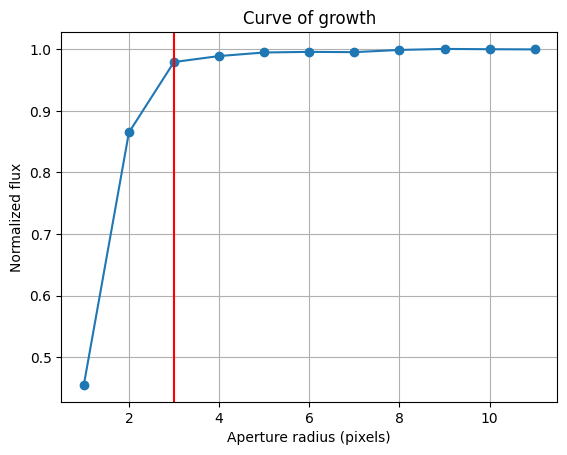

In [18]:
print(f"computing optimal aperture for photometry")

r_opt = get_optimal_aperture(img_sub, sources, max_r=12)

In [19]:
root_dir = "/nexus/posix0/MIA-astro-env/eschinner/jgonzalez/"
outdir = root_dir + "phangs/HST/cats_for_jwst_alignment/"
print(f"compute photometry")

catalog = compute_photometry(img_sub, header, sources, r_opt=r_opt, brightest=500, write=True, outdir=outdir)


compute photometry
using only 500 sources
doing aperture photometry
['id', 'xcenter', 'ycenter', 'aperture_sum', 'sharpness', 'roundness', 'finder_mag', 'peak', 'ra', 'dec', 'finder_flux_abmag', 'aperture_sum_abmag']
writting catalog to /nexus/posix0/MIA-astro-env/eschinner/jgonzalez/phangs/HST/cats_for_jwst_alignment/ngc3596_hst_f814w_cat.fits


In [20]:
print(catalog.colnames)
print(len(catalog))
print(catalog['aperture_sum_abmag'])

['id', 'xcenter', 'ycenter', 'aperture_sum', 'sharpness', 'roundness', 'finder_mag', 'peak', 'ra', 'dec', 'finder_flux_abmag', 'aperture_sum_abmag']
500
aperture_sum_abmag
------------------
16.517764619554857
17.904330419925532
 18.15172276873358
18.154924189752986
19.871576426325753
19.939290427477935
19.965981395670575
19.996591512790072
 20.00577209491222
20.093690753673542
               ...
 24.26007468427099
24.277912433067893
24.328378212952437
 24.33967931882213
   24.356081437158
24.379696996065956
24.424221918732798
 24.52988316415357
24.548748212324845
 24.77790727376822
Length = 500 rows


/tmp/ipykernel_4157492/4173053978.py:3: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.log10(img_sub), origin = 'lower', vmin=3, vmax = 7)
/tmp/ipykernel_4157492/4173053978.py:3: RuntimeWarning: invalid value encountered in log10
  plt.imshow(np.log10(img_sub), origin = 'lower', vmin=3, vmax = 7)


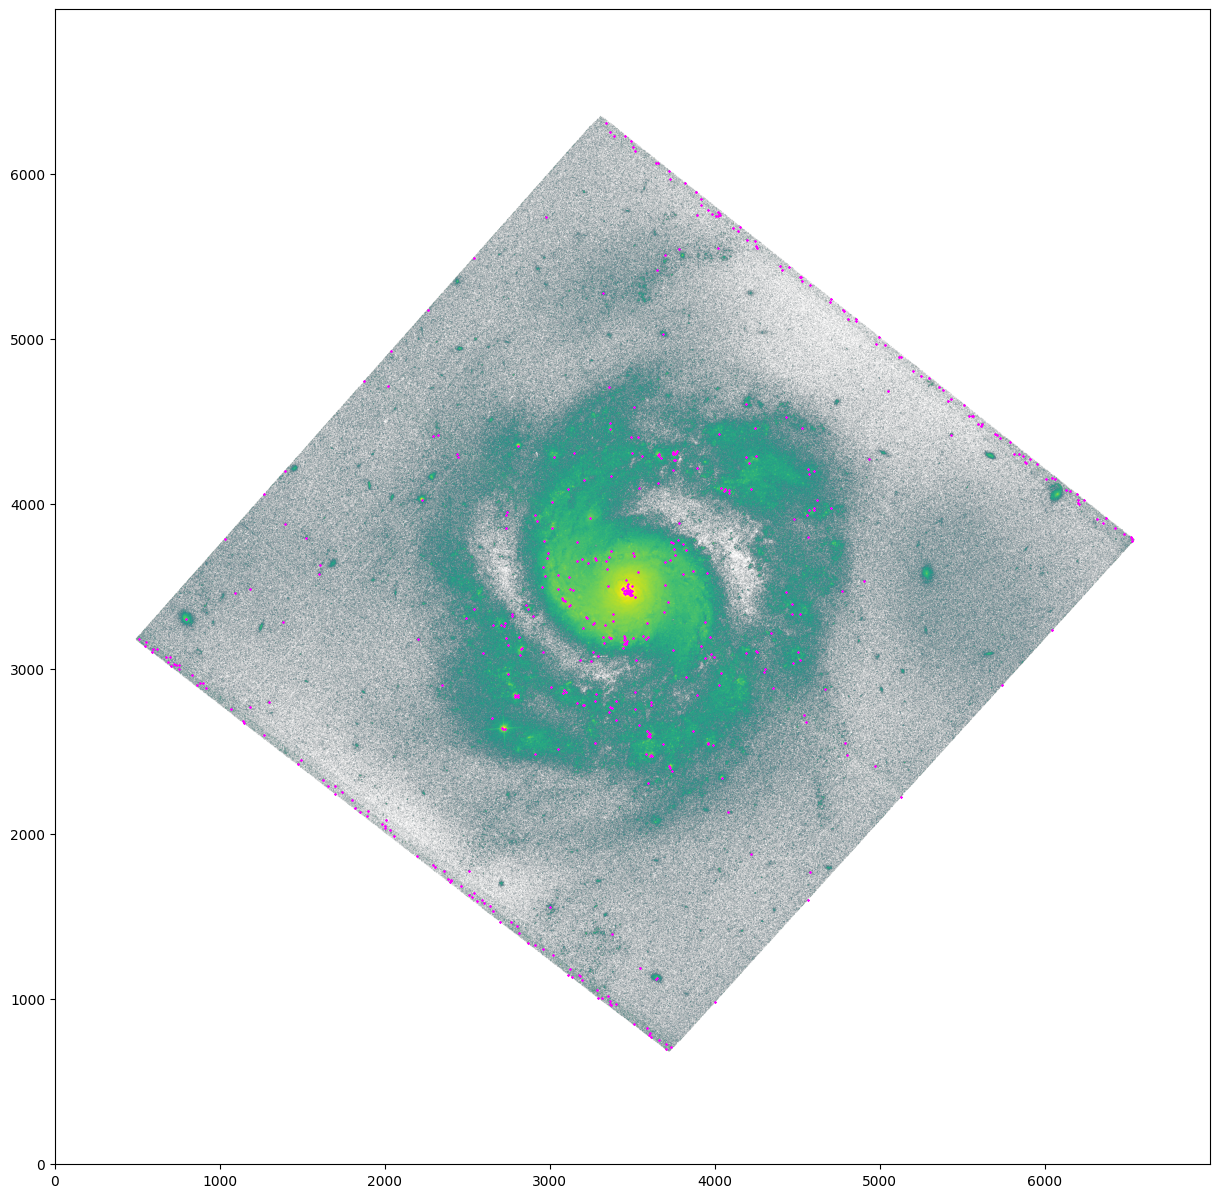

In [21]:
%matplotlib inline
plt.figure(figsize=(15,15))
plt.imshow(np.log10(img_sub), origin = 'lower', vmin=3, vmax = 7)
plt.scatter(catalog['xcenter'], catalog['ycenter'], color='magenta', marker='x', s=1)
plt.show()